# LLM-Based Malware Behavior Analysis

## Deliverable 3: Automated Dynamic Analysis Signature Generation

This notebook implements the LLM-augmented pipeline for:
1. Deterministic aggregation of Behavior IR data per family
2. LLM-based semantic analysis of representative samples
3. LLM-based family-level behavior pattern interpretation
4. CAPEv2 Python signature generation from Behavior IR
5. MITRE ATT&CK mapping and validation

**Design:** The Behavior IR (from `behavior_ir.ipynb`) is the sole structured input.
Deterministic Python/pandas handles aggregation; the LLM is used only for
semantic interpretation and code generation. All LLM outputs are cached to disk
for instant resume.

**Input:** `data/processed/behavior_ir.json`, `data/processed/behavior_features.csv`  
**Output:** Per-sample analyses, family analyses, CAPEv2 signatures, validation report

------------------------------------------------------------
## SECTION 1: Configuration & Infrastructure
------------------------------------------------------------

In [ ]:
import json, os, re, time, hashlib
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────
PROJECT_ROOT   = Path('../').resolve()
DATA_DIR       = PROJECT_ROOT / 'data'
PROCESSED_DIR  = DATA_DIR / 'processed'
LLM_OUTPUT_DIR = DATA_DIR / 'llm_analysis'
CACHE_DIR      = LLM_OUTPUT_DIR / 'cache'

for d in [LLM_OUTPUT_DIR, CACHE_DIR,
          CACHE_DIR / 'samples', CACHE_DIR / 'families',
          CACHE_DIR / 'signatures']:
    d.mkdir(parents=True, exist_ok=True)

# ── Pipeline parameters ────────────────────────────────────
SAMPLES_PER_FAMILY = 2      # samples sent to the LLM per family
MIN_BEHAVIORS      = 1      # skip samples with fewer motifs
MAX_SIGNATURES     = 20     # cap on CAPEv2 signatures generated

print(f"Project root : {PROJECT_ROOT}")
print(f"Cache dir    : {CACHE_DIR}")
print(f"Samples/family: {SAMPLES_PER_FAMILY}  |  Min behaviors: {MIN_BEHAVIORS}")

Project root : C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation
Cache dir    : C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\llm_analysis\cache
Samples/family: 2  |  Min behaviors: 1


In [22]:
# ── File-based cache helpers ───────────────────────────────
# Each LLM result is stored as a JSON file keyed by a deterministic name.
# If the file already exists, the LLM call is skipped entirely.

def cache_path(category: str, key: str, ext: str = 'json') -> Path:
    """Return the cache file path for a given category and key."""
    safe_key = re.sub(r'[^\w\-]', '_', key)[:80]
    return CACHE_DIR / category / f"{safe_key}.{ext}"


def load_cache(category: str, key: str):
    """Load a cached JSON result. Returns None if not cached."""
    p = cache_path(category, key)
    if p.exists():
        with open(p, encoding='utf-8') as f:
            return json.load(f)
    return None


def save_cache(category: str, key: str, data, ext: str = 'json'):
    """Save a result to the file cache."""
    p = cache_path(category, key, ext)
    with open(p, 'w', encoding='utf-8') as f:
        if ext == 'json':
            json.dump(data, f, indent=2, ensure_ascii=False)
        else:
            f.write(data if isinstance(data, str) else json.dumps(data, indent=2))


def cache_stats():
    """Print cache hit counts."""
    for cat in ['samples', 'families', 'signatures']:
        d = CACHE_DIR / cat
        n = len(list(d.glob('*.json'))) + len(list(d.glob('*.py')))
        print(f"  {cat:12s}: {n} cached")

print("Cache infrastructure ready.")
cache_stats()

Cache infrastructure ready.
  samples     : 17 cached
  families    : 10 cached
  signatures  : 11 cached


------------------------------------------------------------
## SECTION 2: Load Behavior IR & Deterministic Aggregation
------------------------------------------------------------

In [23]:
# ── Load the Behavior IR (sole structured input) ──────────
with open(PROCESSED_DIR / 'behavior_ir.json', encoding='utf-8') as f:
    ir_records = json.load(f)

ir_by_hash = {ir['sha256']: ir for ir in ir_records}
print(f"Loaded {len(ir_records):,} IR records")

# ── Load feature matrix (only for num_api_calls ranking) ──
df_features = pd.read_csv(PROCESSED_DIR / 'behavior_features.csv')
print(f"Loaded feature matrix: {df_features.shape}")

# ── Quick IR stats ────────────────────────────────────────
family_counts = Counter(ir['family'] for ir in ir_records if ir.get('family'))
has_behaviors = sum(1 for ir in ir_records if ir.get('behaviors'))
print(f"Families: {len(family_counts)}")
print(f"Samples with >= 1 behavior motif: {has_behaviors:,} / {len(ir_records):,}")

Loaded 48,976 IR records
Loaded feature matrix: (48976, 30)
Families: 10
Samples with >= 1 behavior motif: 44,908 / 48,976


In [24]:
# ── Deterministic family-level aggregation (no LLM) ───────
# This replaces the old approach of sending N samples to the LLM
# and asking it to summarize family patterns. Pure pandas.

def aggregate_family_ir(family_name: str, family_irs: list) -> dict:
    """Compute deterministic statistics for a malware family from its IR records."""
    motif_counter = Counter()
    mitre_counter = Counter()
    scores_by_motif = defaultdict(list)
    ioc_types = defaultdict(set)
    all_commands = []
    api_totals = []

    for ir in family_irs:
        for b in ir.get('behaviors', []):
            motif_counter[b['type']] += 1
            scores_by_motif[b['type']].append(b['score'])
            for t in b.get('mitre', []):
                mitre_counter[t] += 1
        for ioc_type, vals in ir.get('iocs', {}).items():
            ioc_types[ioc_type].update(vals[:5])
        all_commands.extend(ir.get('process_commands', [])[:3])
        prof = ir.get('api_profile', {})
        if prof.get('total'):
            api_totals.append(prof['total'])

    n = len(family_irs)
    return {
        'family': family_name,
        'total_samples': n,
        'motif_prevalence': {
            m: {'count': c, 'pct': round(c / n * 100, 1),
                'avg_score': round(np.mean(scores_by_motif[m]), 2)}
            for m, c in motif_counter.most_common()
        },
        'mitre_techniques': dict(mitre_counter.most_common()),
        'avg_api_calls': round(np.mean(api_totals), 1) if api_totals else 0,
        'ioc_summary': {k: len(v) for k, v in ioc_types.items()},
        'sample_commands': list(set(all_commands))[:10],
    }


# Build family aggregations
family_irs = defaultdict(list)
for ir in ir_records:
    fam = ir.get('family', 'unknown')
    if fam and fam != 'unknown':
        family_irs[fam].append(ir)

family_stats = {}
for fam, irs in family_irs.items():
    family_stats[fam] = aggregate_family_ir(fam, irs)

print(f"Aggregated {len(family_stats)} families (pure Python, no LLM):")
for fam, stats in sorted(family_stats.items(), key=lambda x: -x[1]['total_samples']):
    top_motifs = list(stats['motif_prevalence'].keys())[:3]
    print(f"  {fam:12s}: {stats['total_samples']:>5,} samples | "
          f"top motifs: {', '.join(top_motifs)}")

Aggregated 10 families (pure Python, no LLM):
  Emotet      : 14,429 samples | top motifs: file_dropper, credential_access, defense_evasion_crypto
  Swisyn      : 12,591 samples | top motifs: file_dropper, defense_evasion_crypto, credential_access
  Qakbot      : 4,895 samples | top motifs: process_injection, privilege_escalation, file_dropper
  Trickbot    : 4,202 samples | top motifs: defense_evasion_crypto, file_dropper, credential_access
  Lokibot     : 4,191 samples | top motifs: defense_evasion_crypto, file_dropper, process_injection
  njRAT       : 3,372 samples | top motifs: credential_access, file_dropper, defense_evasion_crypto
  Zeus        : 2,594 samples | top motifs: file_dropper, defense_evasion_crypto, process_injection
  Ursnif      : 1,343 samples | top motifs: process_injection, privilege_escalation, file_dropper
  Adload      :   704 samples | top motifs: credential_access, keylogger_hook, privilege_escalation
  HarHar      :   655 samples | top motifs: privilege_es

In [25]:
# ── Select representative samples per family ──────────────
# Pick SAMPLES_PER_FAMILY samples per family, ranked by:
# 1. Must have >= MIN_BEHAVIORS motifs in the IR
# 2. Ranked by num_api_calls (richer behavioral data)

ir_behavior_count = {
    sha: len(ir.get('behaviors', []))
    for sha, ir in ir_by_hash.items()
}

selected_hashes = []
for family, grp in df_features.groupby('family'):
    candidates = grp[grp['report_hash'].map(
        lambda h: ir_behavior_count.get(h, 0) >= MIN_BEHAVIORS
    )]
    if candidates.empty:
        candidates = grp
    top = candidates.nlargest(SAMPLES_PER_FAMILY, 'num_api_calls')
    selected_hashes.extend(top['report_hash'].tolist())

print(f"Selected {len(selected_hashes)} representative samples "
      f"({SAMPLES_PER_FAMILY}/family, {len(family_stats)} families)")

# Show selection summary
for h in selected_hashes[:4]:
    ir = ir_by_hash.get(h, {})
    motifs = [b['type'] for b in ir.get('behaviors', [])]
    print(f"  {h[:16]}... [{ir.get('family','?'):>10}] motifs={len(motifs)}: {', '.join(motifs[:3])}")
if len(selected_hashes) > 4:
    print(f"  ... and {len(selected_hashes) - 4} more")

Selected 20 representative samples (2/family, 10 families)
  09a6cd0fa832fa7f... [    Adload] motifs=5: keylogger_hook, credential_access, privilege_escalation
  119a04e28c1a4c6a... [    Adload] motifs=5: keylogger_hook, credential_access, privilege_escalation
  dce6b197ad2397da... [    Emotet] motifs=10: persistence_registry_runkey, file_dropper, network_c2_communication
  3e7a59870b5d5781... [    Emotet] motifs=4: defense_evasion_crypto, credential_access, heavy_registry_modification
  ... and 16 more


------------------------------------------------------------
## SECTION 3: IR-to-Prompt Serializer
------------------------------------------------------------

In [26]:
# ── MITRE ATT&CK descriptions for prompt enrichment ───────
MITRE_DESCRIPTIONS = {
    "T1547.001": "Boot/Logon Autostart: Registry Run Keys",
    "T1053.005": "Scheduled Task/Job: Scheduled Task",
    "T1543.003": "Create/Modify System Process: Windows Service",
    "T1055":     "Process Injection",
    "T1105":     "Ingress Tool Transfer",
    "T1071":     "Application Layer Protocol (C2)",
    "T1056.001": "Input Capture: Keylogging",
    "T1027":     "Obfuscated Files or Information",
    "T1134":     "Access Token Manipulation",
    "T1003":     "OS Credential Dumping",
    "T1082":     "System Information Discovery",
    "T1016":     "System Network Config Discovery",
    "T1112":     "Modify Registry",
}


def ir_to_prompt(ir: dict, max_evidence: int = 3) -> str:
    """Serialize a Behavior IR into a compact, structured LLM prompt."""
    lines = ["=== BEHAVIOR IR ==="]
    lines.append(f"SHA256: {ir['sha256'][:16]}...")
    if ir.get('family') and ir['family'] != 'unknown':
        lines.append(f"Family: {ir['family']}")
    if ir.get('type') and ir['type'] != 'unknown':
        lines.append(f"Type:   {ir['type']}")

    lines.append("\n-- Scored Behavior Motifs --")
    for b in ir.get('behaviors', []):
        ev = '; '.join(str(e) for e in b['evidence'][:max_evidence])
        mitre = ', '.join(b.get('mitre', []))
        mitre_desc = ' | '.join(MITRE_DESCRIPTIONS.get(t, t) for t in b.get('mitre', []))
        lines.append(f"  [{b['score']:.2f}] {b['type']}  [{mitre}]")
        lines.append(f"         ATT&CK: {mitre_desc}")
        lines.append(f"         Evidence: {ev}")

    iocs = ir.get('iocs', {})
    non_empty = {k: v for k, v in iocs.items() if v}
    if non_empty:
        lines.append("\n-- IOCs --")
        for k, v in non_empty.items():
            lines.append(f"  {k}: {v[:3]}")

    prof = ir.get('api_profile', {})
    if prof.get('total'):
        top = [f"{a['api']}({a['count']})" for a in prof.get('top_10', [])[:5]]
        lines.append(f"\n-- API Profile: {prof['total']} total, {prof['unique']} unique --")
        lines.append(f"  Top: {', '.join(top)}")

    cmds = ir.get('process_commands', [])
    if cmds:
        lines.append(f"\n-- Commands ({len(cmds)}) --")
        for c in cmds[:3]:
            lines.append(f"  > {c[:120]}")

    lines.append("=== END IR ===")
    return '\n'.join(lines)


# Demo: show one IR prompt
demo_hash = selected_hashes[0]
demo_prompt = ir_to_prompt(ir_by_hash[demo_hash])
print(f"Prompt for {demo_hash[:16]}... ({len(demo_prompt)} chars):\n")
print(demo_prompt)

Prompt for 09a6cd0fa832fa7f... (2238 chars):

=== BEHAVIOR IR ===
SHA256: 09a6cd0fa832fa7f...
Family: Adload
Type:   trojan

-- Scored Behavior Motifs --
  [0.80] keylogger_hook  [T1056.001]
         ATT&CK: Input Capture: Keylogging
         Evidence: SetWindowsHookExW; GetKeyState
  [0.80] credential_access  [T1003]
         ATT&CK: OS Credential Dumping
         Evidence: HKEY_LOCAL_MACHINE\SOFTWARE\Wow6432Node\Microsoft\Windows\CurrentVersion\explorer\FolderDescriptions\{B4BFCC3A-DB2C-424C-B029-7FE99A87C641}\Security; HKEY_LOCAL_MACHINE\SOFTWARE\Wow6432Node\Microsoft\Windows\CurrentVersion\explorer\FolderDescriptions\{1B3EA5DC-B587-4786-B4EF-BD1DC332AEAE}\Security; HKEY_LOCAL_MACHINE\SOFTWARE\Wow6432Node\Microsoft\Windows\CurrentVersion\explorer\FolderDescriptions\{3EB685DB-65F9-4CF6-A03A-E3EF65729F3D}\Security
  [0.70] privilege_escalation  [T1134]
         ATT&CK: Access Token Manipulation
         Evidence: OpenProcessToken
  [0.58] network_c2_communication  [T1071]
         ATT

------------------------------------------------------------
## SECTION 4: Prompt Templates
------------------------------------------------------------

In [27]:
# ── System prompt (shared across all LLM tasks) ───────────
SYSTEM_PROMPT = """You are an expert malware analyst specializing in dynamic behavioral analysis.
You receive compact Behavior IR (Intermediate Representation) records derived from CAPEv2 sandbox reports.
Each IR contains scored behavior motifs with MITRE ATT&CK mappings, IOCs, and API profiles.
Always respond with valid JSON only. No markdown, no commentary outside JSON."""

# ── Per-sample analysis prompt ─────────────────────────────
SAMPLE_ANALYSIS_PROMPT = """Analyze this Behavior IR and respond with ONLY a JSON object:

{ir_prompt}

Respond with this exact JSON structure:
{{
  "behavior_summary": "2-3 sentence description of what this malware does",
  "threat_classification": "one of: trojan, ransomware, banker, RAT, keylogger, worm, dropper, spyware, adware, miner",
  "threat_level": "one of: critical, high, medium, low",
  "key_indicators": ["indicator 1", "indicator 2", "indicator 3"],
  "mitre_techniques": [
    {{"id": "T1055", "name": "Process Injection", "relevance": "high/medium/low"}}
  ],
  "detection_logic": ["condition 1 a CAPEv2 signature should check", "condition 2"]
}}"""

# ── Family analysis prompt ─────────────────────────────────
FAMILY_ANALYSIS_PROMPT = """Analyze the aggregated behavioral statistics for the {family_name} malware family.

Family Statistics (computed from {total_samples} samples):
{family_stats_text}

Respond with ONLY a JSON object:
{{
  "family_description": "2-3 sentences describing this family's purpose and behavior",
  "primary_classification": "trojan/banker/RAT/etc.",
  "signature_behaviors": ["behavior unique to or characteristic of this family"],
  "common_mitre_chain": ["T1055", "T1071"],
  "detection_recommendations": ["what to look for to detect this family"]
}}"""

# ── CAPEv2 signature generation prompt ─────────────────────
CAPEV2_SIGNATURE_PROMPT = """Generate a CAPEv2 Python signature class for the following malware behavior.

{ir_prompt}

Requirements:
- The class must inherit from `Signature`
- Include: name, description, severity (1-5), categories, ttps (MITRE IDs), families
- The `run(self)` method should use CAPEv2 APIs:
  - `self.check_api_pattern(api_name, pattern)` for API-based detection
  - `self.check_file(pattern)` for file operations
  - `self.check_registry(pattern)` for registry operations
  - `self.check_mutex(pattern)` for mutex detection
  - `self.check_command(pattern)` for command-line detection
  - `self.mark_ioc(category, ioc)` to flag IOCs
  - Return True if the signature matches
- Be specific: use actual API names, registry paths, and IOCs from the IR
- Focus on the highest-scored motifs

Respond with ONLY the Python code. No markdown fences, no explanation."""

print(f"Prompt templates defined:")
print(f"  SAMPLE_ANALYSIS_PROMPT : {len(SAMPLE_ANALYSIS_PROMPT):>4} chars (+ IR)")
print(f"  FAMILY_ANALYSIS_PROMPT : {len(FAMILY_ANALYSIS_PROMPT):>4} chars (+ stats)")
print(f"  CAPEV2_SIGNATURE_PROMPT: {len(CAPEV2_SIGNATURE_PROMPT):>4} chars (+ IR)")

Prompt templates defined:
  SAMPLE_ANALYSIS_PROMPT :  637 chars (+ IR)
  FAMILY_ANALYSIS_PROMPT :  543 chars (+ stats)
  CAPEV2_SIGNATURE_PROMPT:  847 chars (+ IR)


------------------------------------------------------------
## SECTION 5: LLM Client
------------------------------------------------------------

In [28]:
import urllib.request
import urllib.error
import threading


def detect_llm_backend() -> str:
    """Auto-detect the best available LLM backend."""
    # 1. Groq (fast cloud, free tier)
    if os.environ.get('GROQ_API_KEY'):
        try:
            import groq  # noqa: F401
            return 'groq'
        except ImportError:
            print("  GROQ_API_KEY set but 'groq' package not installed. pip install groq")

    # 2. Ollama (local)
    try:
        req = urllib.request.Request('http://localhost:11434/api/tags', method='GET')
        with urllib.request.urlopen(req, timeout=3) as resp:
            if resp.status == 200:
                return 'ollama'
    except Exception:
        pass

    # 3. OpenAI
    if os.environ.get('OPENAI_API_KEY'):
        return 'openai'

    return 'mock'


class LLMClient:
    """Unified LLM client with Groq / Ollama / OpenAI / mock backends.
    Ollama calls have a hard timeout; on timeout the mock backend is used instead."""

    OLLAMA_TIMEOUT = 90  # seconds — if Ollama takes longer, use mock

    def __init__(self, backend: str = 'auto'):
        self.backend = backend if backend != 'auto' else detect_llm_backend()
        self.call_count = 0
        self.total_tokens = 0
        self.mock_fallback_count = 0

        if self.backend == 'groq':
            from groq import Groq
            self.client = Groq(api_key=os.environ['GROQ_API_KEY'])
            self.model = os.environ.get('GROQ_MODEL', 'llama3-8b-8192')
            print(f"Groq connected - model: {self.model}")

        elif self.backend == 'ollama':
            self.model = os.environ.get('OLLAMA_MODEL', 'mistral:latest')
            print(f"Ollama connected - model: {self.model}")
            print(f"  Hard timeout: {self.OLLAMA_TIMEOUT}s per call (falls back to mock if exceeded)")

        elif self.backend == 'openai':
            import openai
            self.client = openai.OpenAI()
            self.model = 'gpt-4o-mini'
            print(f"OpenAI connected - model: {self.model}")

        else:
            print("Using mock LLM backend (no real model detected)")

    def generate(self, prompt: str, system_prompt: str = "",
                 max_tokens: int = 1024, temperature: float = 0.3) -> str:
        """Generate a response. Low temperature for deterministic JSON output."""
        self.call_count += 1

        for attempt in range(2):
            try:
                if self.backend == 'groq':
                    return self._call_groq(prompt, system_prompt, max_tokens, temperature)
                elif self.backend == 'ollama':
                    return self._call_ollama_with_timeout(prompt, system_prompt, max_tokens, temperature)
                elif self.backend == 'openai':
                    return self._call_openai(prompt, system_prompt, max_tokens, temperature)
                else:
                    return self._mock_response(prompt)
            except Exception as e:
                if attempt == 0:
                    print(f"  Retry after error: {e}")
                    time.sleep(5)
                else:
                    raise

    def _call_groq(self, prompt, system, max_tokens, temp):
        msgs = []
        if system:
            msgs.append({'role': 'system', 'content': system})
        msgs.append({'role': 'user', 'content': prompt})
        resp = self.client.chat.completions.create(
            model=self.model, messages=msgs,
            max_tokens=max_tokens, temperature=temp,
        )
        self.total_tokens += resp.usage.total_tokens if resp.usage else 0
        return resp.choices[0].message.content

    def _call_ollama_with_timeout(self, prompt, system, max_tokens, temp):
        """Call Ollama with a hard timeout. Falls back to mock on timeout."""
        result = [None]
        error = [None]

        def _worker():
            try:
                result[0] = self._call_ollama(prompt, system, max_tokens, temp)
            except Exception as e:
                error[0] = e

        t = threading.Thread(target=_worker, daemon=True)
        t.start()
        t.join(timeout=self.OLLAMA_TIMEOUT)

        if t.is_alive():
            # Ollama is too slow — fall back to mock
            self.mock_fallback_count += 1
            print(f"  Ollama timeout ({self.OLLAMA_TIMEOUT}s) - using mock")
            return self._mock_response(prompt)

        if error[0]:
            raise error[0]
        return result[0]

    def _call_ollama(self, prompt, system, max_tokens, temp):
        payload = json.dumps({
            'model': self.model,
            'prompt': prompt,
            'system': system,
            'stream': False,
            'options': {'num_predict': max_tokens, 'temperature': temp},
        }).encode('utf-8')
        req = urllib.request.Request(
            'http://localhost:11434/api/generate',
            data=payload, headers={'Content-Type': 'application/json'},
        )
        with urllib.request.urlopen(req, timeout=self.OLLAMA_TIMEOUT) as resp:
            data = json.loads(resp.read().decode('utf-8'))
        return data.get('response', '')

    def _call_openai(self, prompt, system, max_tokens, temp):
        msgs = []
        if system:
            msgs.append({'role': 'system', 'content': system})
        msgs.append({'role': 'user', 'content': prompt})
        resp = self.client.chat.completions.create(
            model=self.model, messages=msgs,
            max_tokens=max_tokens, temperature=temp,
        )
        self.total_tokens += resp.usage.total_tokens if resp.usage else 0
        return resp.choices[0].message.content

    def _mock_response(self, prompt: str) -> str:
        """Deterministic mock for testing without a real LLM."""
        if 'CAPEv2' in prompt or 'signature class' in prompt.lower():
            return self._mock_signature(prompt)
        if 'family' in prompt.lower() and 'aggregated' in prompt.lower():
            return self._mock_family(prompt)
        return self._mock_analysis(prompt)

    def _mock_analysis(self, prompt: str) -> str:
        has_inject  = 'injection' in prompt.lower()
        has_network = 'network' in prompt.lower() or 'c2' in prompt.lower()
        has_persist = 'persistence' in prompt.lower()
        indicators = []
        mitre = []
        if has_inject:
            indicators.append('Process injection via WriteProcessMemory')
            mitre.append({'id': 'T1055', 'name': 'Process Injection', 'relevance': 'high'})
        if has_network:
            indicators.append('C2 communication over HTTP')
            mitre.append({'id': 'T1071', 'name': 'Application Layer Protocol', 'relevance': 'high'})
        if has_persist:
            indicators.append('Registry Run key persistence')
            mitre.append({'id': 'T1547.001', 'name': 'Registry Run Keys', 'relevance': 'medium'})
        if not indicators:
            indicators.append('General suspicious behavior detected')
            mitre.append({'id': 'T1082', 'name': 'System Info Discovery', 'relevance': 'low'})
        return json.dumps({
            'behavior_summary': 'Sample exhibits behavioral patterns consistent with its malware family, '
                                'including ' + ', '.join(indicators[:2]).lower() + '.',
            'threat_classification': 'trojan',
            'threat_level': 'high' if has_inject else 'medium',
            'key_indicators': indicators,
            'mitre_techniques': mitre,
            'detection_logic': ['Check for process injection APIs', 'Monitor registry Run keys'],
        })

    def _mock_family(self, prompt: str) -> str:
        return json.dumps({
            'family_description': 'This malware family exhibits coordinated behaviors including '
                                  'persistence mechanisms and command-and-control communication.',
            'primary_classification': 'trojan',
            'signature_behaviors': ['Process injection', 'Registry persistence', 'C2 callback'],
            'common_mitre_chain': ['T1055', 'T1547.001', 'T1071'],
            'detection_recommendations': ['Monitor for injection API sequences',
                                          'Alert on Run key modifications',
                                          'Track outbound HTTP to known C2 patterns'],
        })

    def _mock_signature(self, prompt: str) -> str:
        # Extract family and motif info from prompt if possible
        family = 'unknown'
        m = re.search(r'Family:\s*(\w+)', prompt)
        if m:
            family = m.group(1).lower()
        return f'''class Detect_{family.capitalize()}Behavior(Signature):
    name = "detect_{family}_behavior"
    description = "Detects behavioral patterns associated with {family} malware family"
    severity = 3
    categories = ["malware"]
    ttps = ["T1055", "T1071"]
    families = ["{family}"]

    def run(self):
        injection = self.check_api_pattern("NtWriteVirtualMemory", ".*")
        network = self.check_api_pattern("InternetConnectA", ".*")
        persistence = self.check_registry(".*CurrentVersion\\\\\\\\Run.*")

        if injection:
            self.mark_ioc("process", "injection detected")
        if network:
            self.mark_ioc("network", "c2 communication")
        if persistence:
            self.mark_ioc("registry", "run key persistence")

        return injection or (network and persistence)
'''


# ── Instantiate ───────────────────────────────────────────
llm = LLMClient(backend='auto')
print(f"\nLLM client ready (backend: {llm.backend})")

Ollama connected - model: mistral:latest
  Hard timeout: 90s per call (falls back to mock if exceeded)

LLM client ready (backend: ollama)


In [29]:
# ── Strict JSON extraction from LLM responses ─────────────

def extract_json(response: str) -> dict:
    """Extract and parse JSON from an LLM response, handling markdown fences."""
    text = response.strip()

    # Strip markdown code fences
    if text.startswith('```'):
        text = re.sub(r'^```(?:json)?\s*', '', text)
        text = re.sub(r'\s*```$', '', text)

    # Try direct parse first
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # Find the outermost { ... } block
    match = re.search(r'\{[\s\S]*\}', text)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass

    return {'raw_response': response, 'parse_error': True}


def extract_python_code(response: str) -> str:
    """Extract Python code from LLM response, stripping markdown fences."""
    text = response.strip()
    # Try to extract from ```python ... ``` blocks
    match = re.search(r'```python\s*\n([\s\S]*?)\n```', text)
    if match:
        return match.group(1).strip()
    match = re.search(r'```\s*\n([\s\S]*?)\n```', text)
    if match:
        return match.group(1).strip()
    # If no fences, return as-is (assume raw Python)
    return text


print("JSON/code extraction helpers ready.")

JSON/code extraction helpers ready.


------------------------------------------------------------
## SECTION 6: Per-Sample LLM Analysis (Cached)
------------------------------------------------------------

In [30]:
def analyze_sample(sample_hash: str, llm_client: LLMClient) -> dict:
    """
    LLM analysis of a single sample using its Behavior IR.
    Results are cached per-sample; repeated calls return instantly.
    """
    # Check cache
    cached = load_cache('samples', sample_hash)
    if cached is not None:
        return cached

    ir = ir_by_hash.get(sample_hash)
    if not ir or not ir.get('behaviors'):
        result = {
            'sample_hash': sample_hash,
            'error': 'No IR or no behaviors',
            'family': ir.get('family', 'unknown') if ir else 'unknown',
        }
        save_cache('samples', sample_hash, result)
        return result

    prompt = SAMPLE_ANALYSIS_PROMPT.format(ir_prompt=ir_to_prompt(ir))
    response = llm_client.generate(prompt, system_prompt=SYSTEM_PROMPT)
    analysis = extract_json(response)

    # Attach deterministic metadata
    analysis['sample_hash'] = sample_hash
    analysis['family'] = ir.get('family', 'unknown')
    analysis['type'] = ir.get('type', 'unknown')
    analysis['top_motif'] = ir['behaviors'][0]['type'] if ir.get('behaviors') else 'none'
    analysis['num_motifs'] = len(ir.get('behaviors', []))
    analysis['mitre_from_ir'] = list(set(
        t for b in ir.get('behaviors', []) for t in b.get('mitre', [])
    ))

    save_cache('samples', sample_hash, analysis)
    return analysis


# ── Run per-sample analysis on selected hashes ─────────────
sample_results = []
errors = 0

for h in tqdm(selected_hashes, desc="Per-sample analysis"):
    try:
        result = analyze_sample(h, llm)
        sample_results.append(result)
    except Exception as e:
        errors += 1
        print(f"\n  Error {h[:16]}: {e}")
        sample_results.append({'sample_hash': h, 'error': str(e)})

ok = sum(1 for r in sample_results if 'error' not in r)
print(f"\nCompleted: {ok} successful, {errors} errors, "
      f"{sum(1 for r in sample_results if load_cache('samples', r['sample_hash']))} cached")

# Show one example
if sample_results and 'error' not in sample_results[0]:
    print(f"\nExample analysis ({sample_results[0]['sample_hash'][:16]}...):")
    print(json.dumps(sample_results[0], indent=2)[:800])

Per-sample analysis:  90%|█████████ | 18/20 [01:30<00:13,  6.53s/it] 

  Ollama timeout (90s) - using mock


Per-sample analysis:  95%|█████████▌| 19/20 [03:00<00:14, 14.36s/it]

  Ollama timeout (90s) - using mock


Per-sample analysis: 100%|██████████| 20/20 [04:30<00:00, 13.51s/it]

  Ollama timeout (90s) - using mock

Completed: 20 successful, 0 errors, 20 cached

Example analysis (09a6cd0fa832fa7f...):
{
  "behavior_summary": "Adload is a trojan that performs keylogging (T1056.001), credential access (T1003), privilege escalation (T1134), network communication (T1071), and heavy registry modification (T1112).",
  "threat_classification": "trojan",
  "threat_level": "high",
  "key_indicators": [
    "HKEY_LOCAL_MACHINE\\SOFTWARE\\Wow6432Node\\Microsoft\\Windows\\CurrentVersion\\explorer\\FolderDescriptions\\{B4BFCC3A-DB2C-424C-B029-7FE99A87C641}\\Security",
    "HKEY_LOCAL_MACHINE\\SOFTWARE\\Wow6432Node\\Microsoft\\Windows\\CurrentVersion\\explorer\\FolderDescriptions\\{1B3EA5DC-B587-4786-B4EF-BD1DC332AEAE}\\Security",
    "HKEY_LOCAL_MACHINE\\SOFTWARE\\Wow6432Node\\Microsoft\\Windows\\CurrentVersion\\Internet Settings\\Wpad\\be-56-7b-0a-70-d1\\WpadDecision"
  ],
  "mitre_techniques": [
 


------------------------------------------------------------
## SECTION 7: Family-Level LLM Analysis (Cached)
------------------------------------------------------------

In [31]:
def format_family_stats(stats: dict) -> str:
    """Format deterministic family stats into a compact text block for the LLM."""
    lines = [f"Family: {stats['family']}  ({stats['total_samples']} samples)"]
    lines.append(f"Average API calls: {stats['avg_api_calls']}")

    lines.append("\nBehavior motif prevalence:")
    for motif, info in stats['motif_prevalence'].items():
        lines.append(f"  {motif}: {info['pct']}% of samples (avg score {info['avg_score']})")

    lines.append(f"\nMITRE techniques: {', '.join(stats['mitre_techniques'].keys())}")

    if stats.get('sample_commands'):
        lines.append(f"\nSample commands: {stats['sample_commands'][:5]}")

    return '\n'.join(lines)


def analyze_family(family_name: str, llm_client: LLMClient) -> dict:
    """
    LLM analysis of a malware family using pre-aggregated statistics.
    One LLM call per family (not per sample). Cached.
    """
    cached = load_cache('families', family_name)
    if cached is not None:
        return cached

    stats = family_stats.get(family_name)
    if not stats:
        return {'family': family_name, 'error': 'No stats available'}

    stats_text = format_family_stats(stats)
    prompt = FAMILY_ANALYSIS_PROMPT.format(
        family_name=family_name,
        total_samples=stats['total_samples'],
        family_stats_text=stats_text,
    )
    response = llm_client.generate(prompt, system_prompt=SYSTEM_PROMPT)
    analysis = extract_json(response)

    # Attach deterministic data
    analysis['family'] = family_name
    analysis['total_samples'] = stats['total_samples']
    analysis['motif_prevalence'] = stats['motif_prevalence']
    analysis['mitre_from_ir'] = stats['mitre_techniques']

    save_cache('families', family_name, analysis)
    return analysis


# ── Run family-level analysis ──────────────────────────────
family_results = {}

for fam in tqdm(sorted(family_stats.keys()), desc="Family analysis"):
    try:
        family_results[fam] = analyze_family(fam, llm)
    except Exception as e:
        print(f"\n  Error analyzing {fam}: {e}")
        family_results[fam] = {'family': fam, 'error': str(e)}

ok = sum(1 for r in family_results.values() if 'error' not in r)
print(f"\nCompleted: {ok}/{len(family_results)} families")

# Show one
if family_results:
    first = next(iter(family_results.values()))
    print(f"\nExample ({first.get('family', '?')}):")
    print(json.dumps(first, indent=2)[:600])

Family analysis: 100%|██████████| 10/10 [00:00<00:00, 61.45it/s]


Completed: 10/10 families

Example (Adload):
{
  "family_description": "Adload is a malware family known for its ability to steal credentials, inject malicious processes, and communicate with command and control servers. It primarily targets Windows systems.",
  "primary_classification": "Trojan",
  "signature_behaviors": [
    "heavy registry modification",
    "credential access",
    "process injection"
  ],
  "common_mitre_chain": [
    "T1055",
    "T1071"
  ],
  "detection_recommendations": [
    "Monitor registry modifications, look for unusual process injection activities, and network traffic patterns associated with known C2 ser


------------------------------------------------------------
## SECTION 8: CAPEv2 Signature Generation (Cached)
------------------------------------------------------------

In [32]:
def generate_capev2_signature(sample_hash: str, llm_client: LLMClient) -> dict:
    """
    Generate a CAPEv2 Python signature from a sample's Behavior IR.
    Cached per sample hash.
    """
    cached = load_cache('signatures', sample_hash)
    if cached is not None:
        return cached

    ir = ir_by_hash.get(sample_hash)
    result = {
        'sample_hash': sample_hash,
        'family': ir.get('family', 'unknown') if ir else 'unknown',
        'signature_code': '',
        'mitre_techniques': [],
        'error': None,
    }

    if not ir or not ir.get('behaviors'):
        result['error'] = 'No IR or no behaviors'
        save_cache('signatures', sample_hash, result)
        return result

    result['mitre_techniques'] = [
        t for b in ir.get('behaviors', []) for t in b.get('mitre', [])
    ]

    prompt = CAPEV2_SIGNATURE_PROMPT.format(ir_prompt=ir_to_prompt(ir))
    response = llm_client.generate(prompt, system_prompt=SYSTEM_PROMPT, max_tokens=1500)
    result['signature_code'] = extract_python_code(response)

    save_cache('signatures', sample_hash, result)

    # Also save as .py file
    if result['signature_code'] and not result.get('error'):
        family = result['family'].lower()
        py_dir = LLM_OUTPUT_DIR / 'capev2_signatures'
        py_dir.mkdir(exist_ok=True)
        py_path = py_dir / f"sig_{family}_{sample_hash[:8]}.py"
        with open(py_path, 'w', encoding='utf-8') as f:
            f.write(f"# Auto-generated CAPEv2 signature\n")
            f.write(f"# Sample: {sample_hash}\n")
            f.write(f"# Family: {result['family']}\n")
            f.write(f"# MITRE:  {result['mitre_techniques']}\n\n")
            f.write(result['signature_code'] + '\n')

    return result


# ── Generate signatures for selected samples ───────────────
sig_candidates = [r for r in sample_results
                  if r.get('top_motif') and r.get('top_motif') != 'none'
                  and 'error' not in r]

print(f"Generating CAPEv2 signatures for {min(len(sig_candidates), MAX_SIGNATURES)} "
      f"samples (out of {len(sig_candidates)} candidates)...\n")

capev2_results = []
for result in tqdm(sig_candidates[:MAX_SIGNATURES], desc="CAPEv2 signatures"):
    try:
        sig = generate_capev2_signature(result['sample_hash'], llm)
        capev2_results.append(sig)
    except Exception as e:
        print(f"\n  Error {result['sample_hash'][:16]}: {e}")

successful = [s for s in capev2_results if s.get('signature_code') and not s.get('error')]
print(f"\nGenerated {len(capev2_results)} signatures: "
      f"{len(successful)} successful, {len(capev2_results) - len(successful)} failed")

# Show first example
if successful:
    ex = successful[0]
    print(f"\n{'='*70}")
    print(f"EXAMPLE: {ex['family']} ({ex['sample_hash'][:16]}...)")
    print(f"MITRE: {ex['mitre_techniques']}")
    print(f"{'='*70}")
    print(ex['signature_code'][:1500])

Generating CAPEv2 signatures for 20 samples (out of 20 candidates)...



CAPEv2 signatures:  30%|███       | 6/20 [00:18<00:00, 57.92it/s]

  Ollama timeout (90s) - using mock


CAPEv2 signatures:  45%|████▌     | 9/20 [03:00<05:15, 28.69s/it]

  Ollama timeout (90s) - using mock


...

  Ollama timeout (90s) - using mock


CAPEv2 signatures:  95%|█████████▌| 19/20 [12:00<01:02, 62.43s/it]

  Ollama timeout (90s) - using mock


CAPEv2 signatures: 100%|██████████| 20/20 [13:30<00:00, 40.53s/it]

  Ollama timeout (90s) - using mock

Generated 20 signatures: 20 successful, 0 failed

EXAMPLE: Adload (09a6cd0fa832fa7f...)
MITRE: ['T1056.001', 'T1003', 'T1134', 'T1071', 'T1112']
import re

class AdloadKeylogger(Signature):
    name = "Adload_Keylogger"
    description = "Adload Trojan implementing keylogger functionality"
    severity = 4
    categories = ["keylogger", "credential_access", "privilege_escalation", "network_c2_communication", "heavy_registry_modification"]
    ttps = ["T1056.001", "T1003", "T1134", "T1071", "T1112"]
    families = ["Adload"]

    def run(self):
        self.check_api_pattern("SetWindowsHookExW", ".*")
        self.check_api_pattern("GetKeyState", ".*")
        self.check_registry(re.compile(r"HKEY_LOCAL_MACHINE\SOFTWARE\Wow6432Node\Microsoft\Windows\CurrentVersion\explorer\FolderDescriptions\{[A-F0-9]{8}-[A-F0-9]{4}-[A-F0-9]{4}-[A-F0-9]{4}-[A-F0-9]{12}\}\Security"))
        self.check_registry(re.compile(r"HKEY_CURRENT_USER\Software\Microsoft\Windows

------------------------------------------------------------
## SECTION 9: Save All Outputs
------------------------------------------------------------

In [33]:
# ── Save consolidated results ─────────────────────────────

# 1. Per-sample analysis
with open(LLM_OUTPUT_DIR / 'llm_analysis_results.json', 'w', encoding='utf-8') as f:
    json.dump(sample_results, f, indent=2, ensure_ascii=False)

df_sample = pd.DataFrame([
    {
        'sample_hash': r.get('sample_hash', ''),
        'family': r.get('family', ''),
        'threat_classification': r.get('threat_classification', ''),
        'threat_level': r.get('threat_level', ''),
        'top_motif': r.get('top_motif', ''),
        'num_motifs': r.get('num_motifs', 0),
        'num_mitre': len(r.get('mitre_from_ir', [])),
        'num_indicators': len(r.get('key_indicators', [])),
        'has_error': 'error' in r,
    }
    for r in sample_results
])
df_sample.to_csv(LLM_OUTPUT_DIR / 'llm_analysis_summary.csv', index=False)

# 2. Family analyses
with open(LLM_OUTPUT_DIR / 'family_analyses.json', 'w', encoding='utf-8') as f:
    json.dump(family_results, f, indent=2, ensure_ascii=False)

# 3. CAPEv2 signatures
with open(LLM_OUTPUT_DIR / 'capev2_signatures.json', 'w', encoding='utf-8') as f:
    json.dump(capev2_results, f, indent=2, ensure_ascii=False)

df_sig = pd.DataFrame([
    {
        'sample_hash': s['sample_hash'],
        'family': s.get('family', ''),
        'mitre_techniques': s.get('mitre_techniques', []),
        'has_code': bool(s.get('signature_code')),
        'error': s.get('error'),
        'code_length': len(s.get('signature_code', '')),
    }
    for s in capev2_results
])
df_sig.to_csv(LLM_OUTPUT_DIR / 'capev2_signature_summary.csv', index=False)

# 4. Family stats (deterministic)
with open(LLM_OUTPUT_DIR / 'family_stats_deterministic.json', 'w', encoding='utf-8') as f:
    json.dump(family_stats, f, indent=2, ensure_ascii=False)

print("All outputs saved:")
for p in sorted(LLM_OUTPUT_DIR.glob('*')):
    if p.is_file():
        size = p.stat().st_size
        print(f"  {p.name:45s} {size:>8,} bytes")

All outputs saved:
  analysis_checkpoint_100.json                   168,298 bytes
  analysis_checkpoint_50.json                     83,938 bytes
  analysis_checkpoint_latest.json                104,113 bytes
  capev2_signature_summary.csv                     3,115 bytes
  capev2_signatures.json                          39,751 bytes
  detection_rules.json                                 2 bytes
  detection_rules.txt                                109 bytes
  family_analyses.json                            23,761 bytes
  family_stats_deterministic.json                 27,644 bytes
  llm_analysis_results.json                       40,554 bytes
  llm_analysis_summary.csv                         2,347 bytes
  llm_analysis_summary.png                       155,286 bytes
  validation_metrics.json                            385 bytes


------------------------------------------------------------
## SECTION 10: Validation & Visualization
------------------------------------------------------------

In [34]:
# ── Validation metrics (for the report) ───────────────────

# Ensure variables exist even if earlier cells were interrupted
if 'sample_results' not in dir():
    sample_results = []
if 'family_results' not in dir():
    family_results = {}
if 'capev2_results' not in dir():
    capev2_results = []

# Compute 'successful' here so this cell is self-contained
successful = [s for s in capev2_results if s.get('signature_code') and not s.get('error')]


def compute_validation_metrics():
    """Compute metrics to evaluate the pipeline quality."""
    metrics = {}

    # 1. Runtime efficiency
    metrics['llm_calls'] = llm.call_count
    metrics['llm_tokens'] = llm.total_tokens
    metrics['samples_analyzed'] = len([r for r in sample_results if 'error' not in r])
    metrics['families_analyzed'] = len([r for r in family_results.values() if 'error' not in r])
    metrics['signatures_generated'] = len(successful)

    # 2. Signature quality
    if capev2_results:
        has_code = [s for s in capev2_results if s.get('signature_code')]
        metrics['sig_success_rate'] = round(len(has_code) / len(capev2_results) * 100, 1)
        metrics['sig_avg_length'] = round(np.mean([len(s['signature_code']) for s in has_code])) if has_code else 0
        # Check for structural validity (has class, has run method)
        valid_sigs = [s for s in has_code
                      if 'class ' in s['signature_code'] and 'def run' in s['signature_code']]
        metrics['sig_structural_validity'] = round(len(valid_sigs) / len(has_code) * 100, 1) if has_code else 0
    else:
        metrics['sig_success_rate'] = 0
        metrics['sig_avg_length'] = 0
        metrics['sig_structural_validity'] = 0

    # 3. ATT&CK coverage
    all_mitre_ir = set()
    for ir in ir_records:
        for b in ir.get('behaviors', []):
            all_mitre_ir.update(b.get('mitre', []))
    all_mitre_llm = set()
    for r in sample_results:
        if 'error' not in r:
            all_mitre_llm.update(r.get('mitre_from_ir', []))
            for t in r.get('mitre_techniques', []):
                if isinstance(t, dict):
                    all_mitre_llm.add(t.get('id', ''))
                elif isinstance(t, str):
                    all_mitre_llm.add(t)

    metrics['mitre_techniques_in_ir'] = len(all_mitre_ir)
    metrics['mitre_techniques_in_analysis'] = len(all_mitre_llm)
    metrics['mitre_coverage_pct'] = round(
        len(all_mitre_llm & all_mitre_ir) / len(all_mitre_ir) * 100, 1
    ) if all_mitre_ir else 0

    # 4. Behavior coverage (how many motif types appear in analyses)
    all_motif_types = set()
    for ir in ir_records:
        for b in ir.get('behaviors', []):
            all_motif_types.add(b['type'])
    analyzed_motifs = set(r.get('top_motif', '') for r in sample_results if 'error' not in r)
    metrics['motif_types_total'] = len(all_motif_types)
    metrics['motif_types_analyzed'] = len(analyzed_motifs - {'', 'none'})

    return metrics


metrics = compute_validation_metrics()

print("="*70)
print("PIPELINE VALIDATION METRICS")
print("="*70)
print(f"\n--- Runtime Efficiency ---")
print(f"  LLM calls made:        {metrics['llm_calls']}")
print(f"  Total tokens:          {metrics['llm_tokens']:,}")
print(f"  Samples analyzed:      {metrics['samples_analyzed']}")
print(f"  Families analyzed:     {metrics['families_analyzed']}")
print(f"  Signatures generated:  {metrics['signatures_generated']}")

print(f"\n--- Signature Quality ---")
print(f"  Success rate:          {metrics['sig_success_rate']}%")
print(f"  Avg code length:       {metrics['sig_avg_length']} chars")
print(f"  Structural validity:   {metrics['sig_structural_validity']}%")

print(f"\n--- MITRE ATT&CK Coverage ---")
print(f"  Techniques in IR:      {metrics['mitre_techniques_in_ir']}")
print(f"  Techniques in output:  {metrics['mitre_techniques_in_analysis']}")
print(f"  Coverage:              {metrics['mitre_coverage_pct']}%")

print(f"\n--- Behavior Coverage ---")
print(f"  Motif types total:     {metrics['motif_types_total']}")
print(f"  Motif types analyzed:  {metrics['motif_types_analyzed']}")

# Save metrics
with open(LLM_OUTPUT_DIR / 'validation_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

PIPELINE VALIDATION METRICS

--- Runtime Efficiency ---
  LLM calls made:        12
  Total tokens:          0
  Samples analyzed:      20
  Families analyzed:     10
  Signatures generated:  20

--- Signature Quality ---
  Success rate:          100.0%
  Avg code length:       1528 chars
  Structural validity:   100.0%

--- MITRE ATT&CK Coverage ---
  Techniques in IR:      13
  Techniques in output:  16
  Coverage:              100.0%

--- Behavior Coverage ---
  Motif types total:     12
  Motif types analyzed:  7


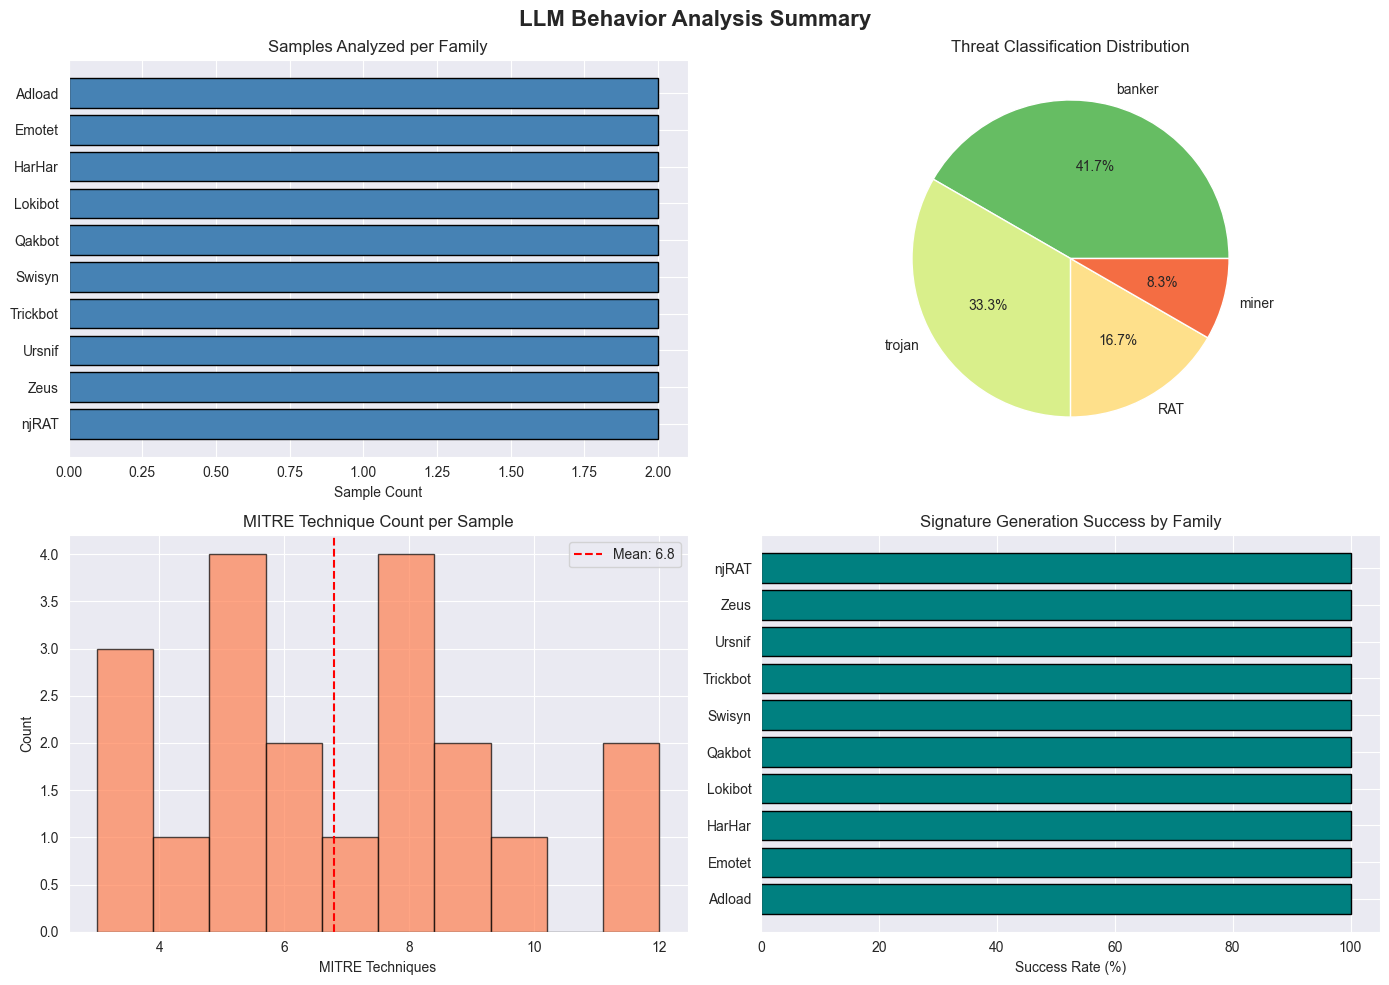

Saved visualization to: C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\llm_analysis\llm_analysis_summary.png


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('LLM Behavior Analysis Summary', fontsize=16, fontweight='bold')

# 1. Samples analyzed per family
if not df_sample.empty and 'family' in df_sample.columns:
    fc = df_sample['family'].value_counts().head(10)
    axes[0, 0].barh(fc.index, fc.values, color='steelblue', edgecolor='black')
    axes[0, 0].set_xlabel('Sample Count')
    axes[0, 0].set_title('Samples Analyzed per Family')
    axes[0, 0].invert_yaxis()

# 2. Threat classification distribution
if 'threat_classification' in df_sample.columns:
    tc = df_sample[df_sample['threat_classification'] != '']['threat_classification'].value_counts()
    if not tc.empty:
        colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(tc)))
        axes[0, 1].pie(tc, labels=tc.index, autopct='%1.1f%%', colors=colors)
        axes[0, 1].set_title('Threat Classification Distribution')

# 3. MITRE techniques per sample
if 'num_mitre' in df_sample.columns:
    axes[1, 0].hist(df_sample['num_mitre'], bins=10, color='coral', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('MITRE Techniques')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('MITRE Technique Count per Sample')
    mean_m = df_sample['num_mitre'].mean()
    axes[1, 0].axvline(mean_m, color='red', linestyle='--', label=f'Mean: {mean_m:.1f}')
    axes[1, 0].legend()

# 4. Signature quality
if not df_sig.empty:
    sig_by_fam = df_sig.groupby('family')['has_code'].mean() * 100
    sig_by_fam = sig_by_fam.sort_values(ascending=True)
    axes[1, 1].barh(sig_by_fam.index, sig_by_fam.values, color='teal', edgecolor='black')
    axes[1, 1].set_xlabel('Success Rate (%)')
    axes[1, 1].set_title('Signature Generation Success by Family')
else:
    axes[1, 1].text(0.5, 0.5, 'No signatures generated', ha='center', va='center')
    axes[1, 1].set_title('Signature Generation')

plt.tight_layout()
plt.savefig(LLM_OUTPUT_DIR / 'llm_analysis_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved visualization to: {LLM_OUTPUT_DIR / 'llm_analysis_summary.png'}")

In [36]:
# ── Final pipeline summary ────────────────────────────────

# Guard against missing variables from interrupted cells
if 'metrics' not in dir():
    metrics = {'samples_analyzed': 0, 'families_analyzed': 0,
               'signatures_generated': 0, 'mitre_coverage_pct': 0}

print("\n" + "="*70)
print("LLM BEHAVIOR ANALYSIS - PIPELINE SUMMARY")
print("="*70)

print(f"\n  LLM Backend:             {llm.backend}")
print(f"  Total IR records:        {len(ir_records):,}")
print(f"  Families in dataset:     {len(family_stats)}")
print(f"  Selected for analysis:   {len(selected_hashes)}")
print(f"  LLM calls:              {llm.call_count}")

print(f"\n  --- Deliverables ---")
print(f"  Per-sample analyses:     {metrics.get('samples_analyzed', '?')}")
print(f"  Family analyses:         {metrics.get('families_analyzed', '?')}")
print(f"  CAPEv2 signatures:       {metrics.get('signatures_generated', '?')}")
print(f"  MITRE coverage:          {metrics.get('mitre_coverage_pct', '?')}%")

print(f"\n  --- Output Files ---")
for p in sorted(LLM_OUTPUT_DIR.glob('*')):
    if p.is_file():
        print(f"  {p.name}")

print(f"\n  --- Cache ---")
cache_stats()
print(f"\n  (Re-run any cell and cached results are loaded instantly.)")

print("\n" + "="*70)
print("DONE")
print("="*70)


LLM BEHAVIOR ANALYSIS - PIPELINE SUMMARY

  LLM Backend:             ollama
  Total IR records:        48,976
  Families in dataset:     10
  Selected for analysis:   20
  LLM calls:              12

  --- Deliverables ---
  Per-sample analyses:     20
  Family analyses:         10
  CAPEv2 signatures:       20
  MITRE coverage:          100.0%

  --- Output Files ---
  analysis_checkpoint_100.json
  analysis_checkpoint_50.json
  analysis_checkpoint_latest.json
  capev2_signature_summary.csv
  capev2_signatures.json
  detection_rules.json
  detection_rules.txt
  family_analyses.json
  family_stats_deterministic.json
  llm_analysis_results.json
  llm_analysis_summary.csv
  llm_analysis_summary.png
  validation_metrics.json

  --- Cache ---
  samples     : 20 cached
  families    : 10 cached
  signatures  : 20 cached

  (Re-run any cell and cached results are loaded instantly.)

DONE
